# Spherical Neural Operators for Global Forecasting

The previous notebook used a Fourier Neural Operator (FNO) on a flat, periodic square. That was the right setting for learning the basic idea: use a spectral transform, modify selected modes with learned weights, and transform back.

Global weather fields are different. They live on a sphere, even when we store them as latitude-longitude arrays. This notebook focuses on the geometric step between the flat FNO and global neural forecast models.

We will not train FourCastNet, implement a production Spherical Fourier Neural Operator (SFNO), or run a pretrained model here. The goal is narrower:

1. See why a latitude-longitude image is not a flat image.
2. Understand area weighting for global fields.
3. Introduce spherical harmonics as the sphere's analogue of Fourier modes.
4. Compare the conceptual FNO and SFNO update rules.
5. Set up the next notebook, where we move from spectral bases to graph-based weather operators.

References:

- Fourier Neural Operator: [Li et al., 2020](https://arxiv.org/abs/2010.08895)
- FourCastNet: [Pathak et al., 2022](https://arxiv.org/abs/2202.11214)
- Spherical Fourier Neural Operators: [Bonev et al., 2023](https://research.nvidia.com/publication/2023-06_spherical-fourier-neural-operators-learning-stable-dynamics-sphere)

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from scipy import special

rng = np.random.default_rng(4)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = False
plt.rcParams['image.cmap'] = 'turbo'

## 1. Why latitude-longitude is not a flat image

A regular latitude-longitude array looks like an image: rows are latitudes, columns are longitudes. But the physical geometry is not image-like.

- Longitude is periodic: $0^\circ$ and $360^\circ$ are the same meridian.
- Latitude is not periodic: the grid ends at the poles.
- A one-degree longitude step is wide at the equator and tiny near the poles.
- A grid cell's physical area is approximately proportional to $\cos(\phi)$, where $\phi$ is latitude.

A flat 2D FFT treats the two coordinate directions as if they were uniform periodic directions. That is a good assumption on a torus, but not on Earth.

## 2. Area weighting changes global scores

For a global field, a score like RMSE should approximate an integral over the sphere:

$$
\operatorname{RMSE}^2 \approx \frac{\sum_i w_i (\hat{x}_i - x_i)^2}{\sum_i w_i}.
$$

On a regular latitude-longitude grid, the simplest latitude weight is

$$
w_i = \cos(\phi_i).
$$

The next example builds two forecasts with similar-looking error amplitudes. One is wrong near the equator; the other is wrong near the poles. The unweighted score treats each grid point equally. The area-weighted score treats each physical area more equally.

Forecast error comparison
------------------------------------------------------------
case                       unweighted   area-weighted
equator-focused error          0.1245          0.1559
pole-focused error             0.1312          0.0840


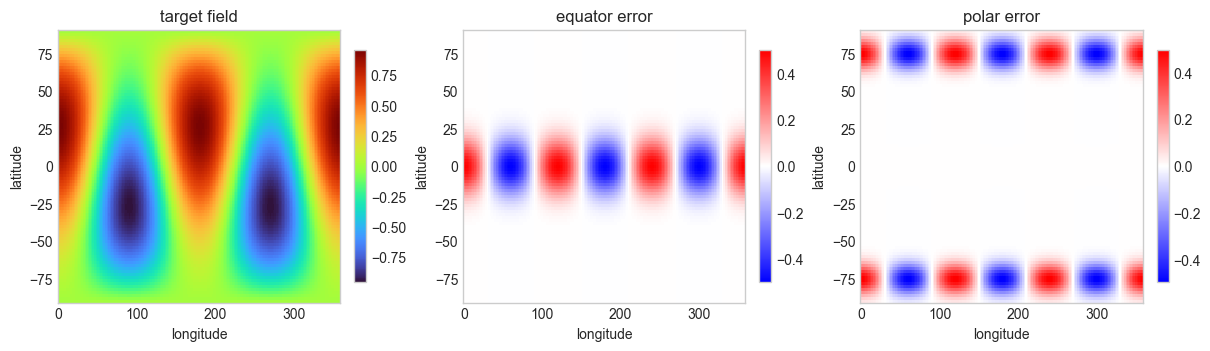

In [3]:
def weighted_rmse(pred, truth, weights=None):
    err2 = (pred - truth) ** 2
    if weights is None:
        return np.sqrt(np.mean(err2))
    return np.sqrt(np.sum(weights * err2) / np.sum(weights))

truth = (
    0.8 * np.cos(np.deg2rad(Lat)) * np.cos(np.deg2rad(2 * Lon))
    + 0.3 * np.sin(np.deg2rad(2 * Lat))
)

equator_error = 0.5 * np.exp(-(Lat / 18) ** 2) * np.cos(np.deg2rad(3 * Lon))
pole_error = 0.5 * np.exp(-((np.abs(Lat) - 75) / 10) ** 2) * np.cos(np.deg2rad(3 * Lon))

forecast_equator_bad = truth + equator_error
forecast_pole_bad = truth + pole_error

rows = []
for name, pred in [
    ('equator-focused error', forecast_equator_bad),
    ('pole-focused error', forecast_pole_bad),
]:
    rows.append((name, weighted_rmse(pred, truth), weighted_rmse(pred, truth, area_weight)))

print('Forecast error comparison')
print('-' * 60)
print(f"{'case':24s} {'unweighted':>12s} {'area-weighted':>15s}")
for name, unweighted, weighted in rows:
    print(f'{name:24s} {unweighted:12.4f} {weighted:15.4f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
plot_data = [truth, equator_error, pole_error]
titles = ['target field', 'equator error', 'polar error']
cmaps = ['turbo', 'bwr', 'bwr']

for ax, data, title, cmap in zip(axes, plot_data, titles, cmaps):
    if cmap == 'bwr':
        vmax = np.max(np.abs(data))
        im = ax.pcolormesh(lon, lat, data, shading='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    else:
        im = ax.pcolormesh(lon, lat, data, shading='auto', cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

The polar error covers many latitude-longitude pixels, but those pixels represent less physical area. Area weighting therefore reduces its influence compared with an image-style score.

This matters for both training losses and forecast verification. Global weather models are usually evaluated with latitude-weighted versions of RMSE, anomaly correlation, or related metrics.

## 3. Spherical harmonics: Fourier modes on the sphere

Fourier modes are natural basis functions on periodic lines, planes, and boxes. On the sphere, the analogous basis functions are **spherical harmonics**.

A spherical harmonic is indexed by two integers:

- degree $\ell$: total spatial scale or complexity,
- order $m$: longitudinal wave structure, with $-\ell \le m \le \ell$.

Low $\ell$ modes describe planetary-scale structure. Higher $\ell$ modes describe smaller spatial scales. A smooth global field can be represented by a weighted sum of these basis functions:

$$
q(\theta, \lambda) = \sum_{\ell=0}^{L}\sum_{m=-\ell}^{\ell} \hat{q}_{\ell m}Y_{\ell}^{m}(\theta, \lambda),
$$

where $\theta$ is colatitude and $\lambda$ is longitude.

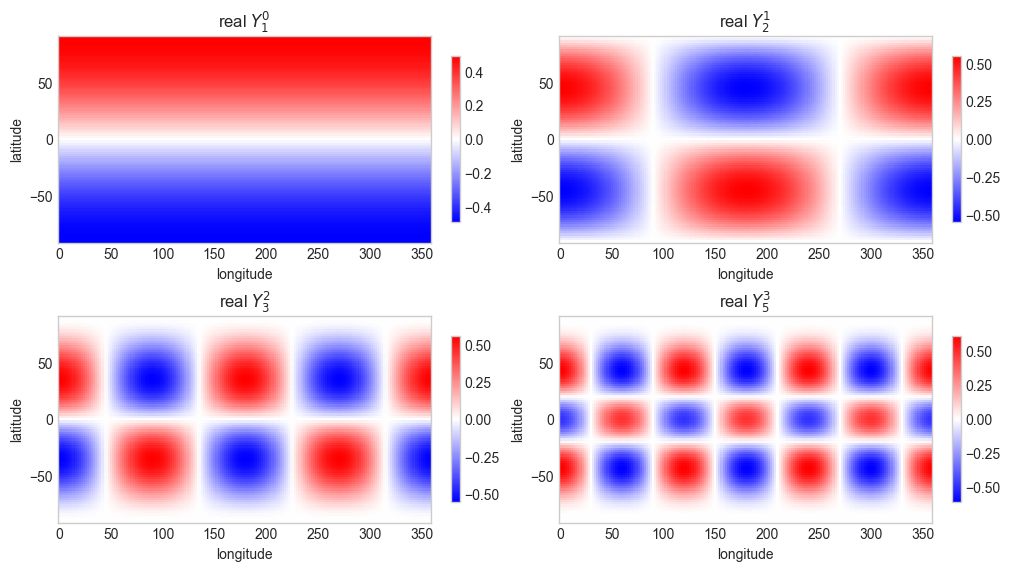

In [4]:
def complex_spherical_harmonic(ell, m, lon_deg, lat_deg):
    """Return complex Y_ell^m on a lat-lon grid.

    SciPy's newer sph_harm_y uses (ell, m, colatitude, longitude).
    The older sph_harm uses (m, ell, longitude, colatitude).
    """
    theta = np.deg2rad(90 - lat_deg)  # colatitude: 0 at north pole
    phi = np.deg2rad(lon_deg)         # longitude / azimuth
    if hasattr(special, 'sph_harm_y'):
        return special.sph_harm_y(ell, m, theta, phi)
    return special.sph_harm(m, ell, phi, theta)


def real_spherical_harmonic(ell, m, lon_deg, lat_deg):
    """A real-valued spherical harmonic pattern for plotting."""
    y = complex_spherical_harmonic(ell, abs(m), lon_deg, lat_deg)
    if m < 0:
        return np.sqrt(2) * (-1) ** m * y.imag
    if m > 0:
        return np.sqrt(2) * (-1) ** m * y.real
    return y.real

patterns = [(1, 0), (2, 1), (3, 2), (5, 3)]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), constrained_layout=True)

for ax, (ell, m) in zip(axes.flat, patterns):
    field = real_spherical_harmonic(ell, m, Lon, Lat)
    vmax = np.max(np.abs(field))
    im = ax.pcolormesh(lon, lat, field, shading='auto', cmap='bwr', vmin=-vmax, vmax=vmax)
    ax.set_title(f'real $Y_{{{ell}}}^{{{m}}}$')
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

These plots are displayed on a rectangular map, but the functions are defined on the sphere. That distinction is the point: spherical harmonics give us global modes that respect spherical geometry, even if the data are stored in a rectangular array.

## 4. From FNO to SFNO

The FNO layer from the previous notebook can be summarized as

$$
v_{j+1}(x) = \sigma\left(Wv_j(x) + \mathcal{F}^{-1}\left(R_\theta(k)\,\mathcal{F}[v_j](k)\right)(x)\right),
$$

where $\mathcal{F}$ is a Fourier transform on a rectangular periodic grid and $R_\theta(k)$ is a learned channel-mixing matrix for selected Fourier modes.

A spherical version keeps the same operator-learning structure but changes the transform:

$$
v_{j+1}(\theta, \lambda) = \sigma\left(Wv_j(\theta, \lambda) + \mathcal{S}^{-1}\left(R_\theta(\ell,m)\,\mathcal{S}[v_j](\ell,m)\right)(\theta, \lambda)\right),
$$

where $\mathcal{S}$ is a spherical harmonic transform.

The analogy is direct:

| Flat FNO | Spherical FNO |
|---|---|
| field on a periodic rectangle | field on the sphere |
| FFT | spherical harmonic transform |
| Fourier mode index $k$ | spherical mode index $(\ell,m)$ |
| learned mode mixing $R_\theta(k)$ | learned mode mixing $R_\theta(\ell,m)$ |
| inverse FFT | inverse spherical harmonic transform |

The important point is not that spherical harmonics automatically produce a good weather model. The point is that the global mixing operation is aligned with the geometry of Earth.

In [5]:
# Coefficient-space sketch only: this is not a full SFNO implementation.
# Suppose a field has input/output channels and we keep degrees ell < L_keep.
C_in = 4
C_out = 6
L_keep = 8

# Number of (ell, m) coefficient slots if we keep all orders for ell < L_keep.
n_modes = sum(2 * ell + 1 for ell in range(L_keep))
coefficients = rng.normal(size=(C_in, n_modes))
learned_mixing = rng.normal(scale=0.1, size=(C_out, C_in, n_modes))

# Each retained spherical mode gets its own learned channel-mixing matrix.
updated_coefficients = np.einsum('ocm,cm->om', learned_mixing, coefficients)

print(f'input coefficients:  {coefficients.shape}')
print(f'mode slots kept:      {n_modes}')
print(f'output coefficients: {updated_coefficients.shape}')

input coefficients:  (4, 64)
mode slots kept:      64
output coefficients: (6, 64)


A production SFNO has many additional details: efficient spherical harmonic transforms, truncation choices, nonlinearities between layers, normalization, dealiasing or filtering, grid conventions, and rollout stability. But at the level of operator learning, the shift is simple:

> replace flat spectral coordinates with spherical spectral coordinates.

## 5. What this explains about global neural forecasting

A global weather forecast model learns a time-step operator such as

$$
\mathcal{G}_\theta: X_t(\lambda, \phi) \mapsto X_{t+6h}(\lambda, \phi),
$$

where $X_t$ is a multi-channel atmospheric state: winds, temperature, humidity, geopotential, surface pressure, and other variables on pressure levels or at the surface.

FourCastNet-style models use neural forecast operators and autoregressive rollout:

```text
X_t       -> model -> X_{t+6h}
X_{t+6h}  -> model -> X_{t+12h}
X_{t+12h} -> model -> X_{t+18h}
...
```

This notebook explains one major design question for such models: **how should the model mix information across a global spherical domain?**

Spherical spectral methods answer this with spherical harmonic transforms. The next notebook introduces a different answer: use a graph or mesh, then learn how information moves along edges.

## 6. Takeaways

- A latitude-longitude array is rectangular in memory but spherical in geometry.
- Longitude is periodic, latitude is not, and grid-cell area changes with latitude.
- Area weighting is essential for global losses and forecast metrics.
- Spherical harmonics are the sphere's analogue of Fourier modes.
- An SFNO keeps the FNO idea but replaces the FFT with a spherical harmonic transform.
- This is one route to global neural forecasting. Another route, used by graph-based models and modern AIFS-style systems, is to represent the atmosphere on a graph or latent mesh.